<a href="https://colab.research.google.com/github/ankitkparashar/python/blob/main/CSML/Module2/CreditCardFraudDetection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub

In [2]:
# Credit Card Fraud detection dataset
path = kagglehub.dataset_download("mlg-ulb/creditcardfraud")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'creditcardfraud' dataset.
Path to dataset files: /kaggle/input/creditcardfraud


In [3]:
card_df = pd.read_csv(path+str('/creditcard.csv'))
card_df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


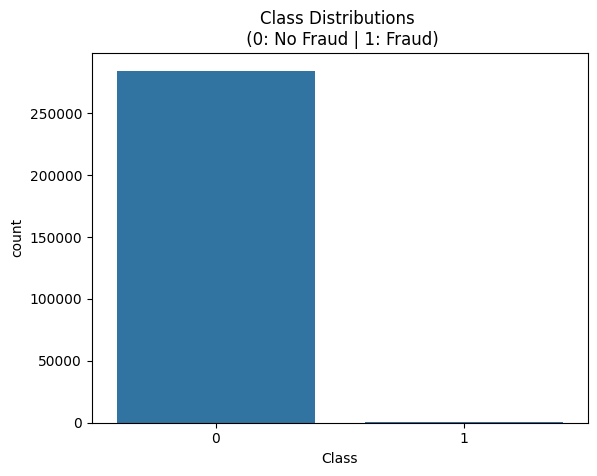

In [4]:
# Plot the target Class
sns.countplot(x='Class', data=card_df)
plt.title('Class Distributions \n (0: No Fraud | 1: Fraud)')
plt.show()

In [5]:
card_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [6]:
card_df.isnull().sum()

,0
Time,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0


In [7]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

In [8]:
#Delete the Time attribute

def get_preprocessed_data(df=None):
  df_copy = df.copy()
  df_copy.drop('Time', axis=1, inplace=True)
  return df_copy

In [9]:
def get_train_test_data(df=None):
  df_copy = get_preprocessed_data(df)
  y = df_copy['Class']
  X = df_copy.drop('Class', axis=1)
  X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0, stratify=y)
  return X_train, X_test, y_train, y_test


X_train, X_test, y_train, y_test = get_train_test_data(card_df)

In [10]:
print("Training Data Label/Value Ratio")
print(y_train.value_counts() / y_train.shape[0] * 100)
print("\nTesting Data Label/Value Ratio")
print(y_test.value_counts() / y_test.shape[0] * 100)

Training Data Label/Value Ratio
Class
0    99.827075
1     0.172925
Name: count, dtype: float64

Testing Data Label/Value Ratio
Class
0    99.827955
1     0.172045
Name: count, dtype: float64


In [11]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, precision_score, recall_score, f1_score, roc_curve, auc, precision_recall_curve, roc_auc_score

In [12]:
def get_clf_eval(y_test=None, y_pred=None, pred_proba=None):
  accuracy = accuracy_score(y_test, y_pred)
  precision = precision_score(y_test, y_pred)
  recall = recall_score(y_test, y_pred)
  f1 = f1_score(y_test, y_pred)
  roc_auc = roc_auc_score(y_test, y_pred)
  print('Confusion Matrix')
  print(confusion_matrix(y_test, y_pred))
  print('\n')
  print('Accuracy: {:.4f}'.format(accuracy))
  print('Precision: {:.4f}'.format(precision))
  print('Recall: {:.4f}'.format(recall))
  print('F1: {:.4f}'.format(f1))
  print('ROC AUC: {:.4f}'.format(roc_auc))

In [13]:
lr_clf = LogisticRegression()
lr_clf.fit(X_train, y_train)
lr_pred = lr_clf.predict(X_test)
lr_pred_proba = lr_clf.predict_proba(X_test)[:, 1]
get_clf_eval(y_test, lr_pred, lr_pred_proba)

Confusion Matrix
[[56855     9]
 [   43    55]]


Accuracy: 0.9991
Precision: 0.8594
Recall: 0.5612
F1: 0.6790
ROC AUC: 0.7805


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


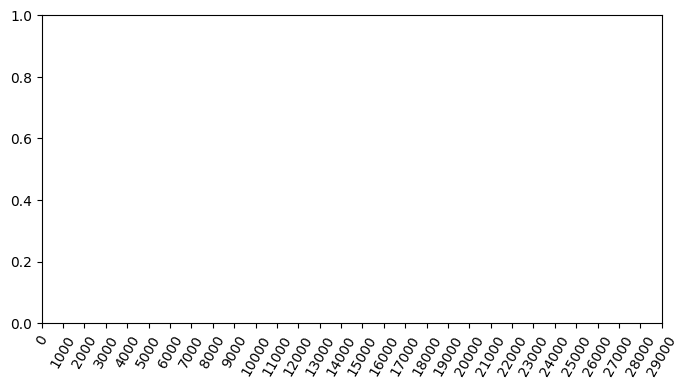

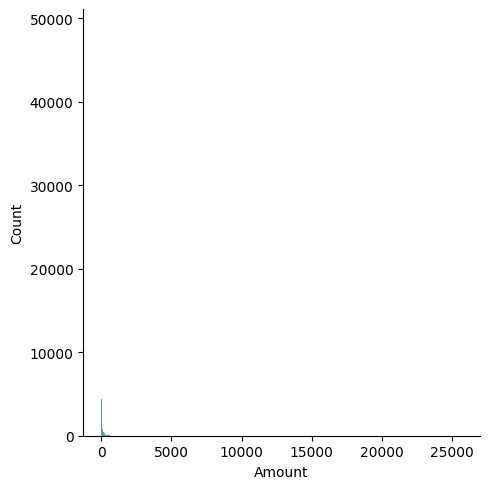

In [15]:
import seaborn as sns

plt.figure(figsize=(8, 4))
plt.xticks(range(0, 30000, 1000), rotation=60)
sns.displot(card_df['Amount'])
plt.show()

In [16]:
def get_preprocessed_data(df=None):
  df_copy = df.copy()
  scaler = StandardScaler()
  amount_n = scaler.fit_transform(df_copy['Amount'].values.reshape(-1, 1))
  df_copy.loc[:, 'Amount'] = amount_n
  df_copy.drop(['Time', 'Amount'], axis=1, inplace=True)
  return df_copy

In [17]:
X_test, X_train, y_test, y_train = get_train_test_data(card_df)

In [18]:
print("## Logistic Regression Classifier ##")

lr_clf = LogisticRegression()
lr_clf.fit(X_train, y_train)
lr_pred = lr_clf.predict(X_test)
lr_pred_proba = lr_clf.predict_proba(X_test)[:, 1]
get_clf_eval(y_test, lr_pred, lr_pred_proba)


## Logistic Regression Classifier ##
Confusion Matrix
[[227416     35]
 [   165    229]]


Accuracy: 0.9991
Precision: 0.8674
Recall: 0.5812
F1: 0.6960
ROC AUC: 0.7905


In [19]:
def get_preprocessed_df(df=None):
  df_copy = df.copy()
  amount_n = np.log1p(df_copy['Amount'])
  df_copy.loc[:, 'Amount'] = amount_n
  df_copy.drop(['Time', 'Amount'], axis=1, inplace=True)
  return df_copy

In [20]:
X_train, X_test, y_train, y_test = get_train_test_data(card_df)

print("## Logistic Regression Classifier ##")

lr_clf = LogisticRegression()
lr_clf.fit(X_train, y_train)
lr_pred = lr_clf.predict(X_test)

get_clf_eval(y_test, lr_pred, lr_pred_proba)

## Logistic Regression Classifier ##
Confusion Matrix
[[56853    11]
 [   37    61]]


Accuracy: 0.9992
Precision: 0.8472
Recall: 0.6224
F1: 0.7176
ROC AUC: 0.8111
